# Sentiment Analysis on Movie Reviews

A compact NLP practical using a small local teaching dataset.


## my goal

Clean review text, create TF-IDF features, compare two classifiers and save a reusable sentiment pipeline.


## 1. imports

The dataset is included in the Day 5 practical folder. No Kaggle, NLTK download or Google Drive connection is needed.


In [1]:
from pathlib import Path
import re
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

DATA_DIR = Path("day_5/Pracs")
if not DATA_DIR.exists():
    DATA_DIR = Path(".")
MODEL_DIR = DATA_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

## 2. loading and inspect the reviews


In [2]:
reviews = pd.read_csv(DATA_DIR / "movie_reviews.csv")
print(f"Rows: {len(reviews)} | Missing values: {reviews.isna().sum().sum()}")
reviews.head()

Rows: 60 | Missing values: 0


,review,sentiment
0,A brilliant film with wonderful acting and a m...,positive
1,I loved the characters and the beautiful endin...,positive
2,Excellent performances made this movie unforge...,positive
3,"The story was engaging, warm and surprisingly ...",positive
4,A fantastic movie that I would happily watch a...,positive


In [3]:
reviews["sentiment"].value_counts().to_frame("Reviews")

,Reviews
sentiment,
positive,30
negative,30


This is a balanced teaching dataset with short synthetic reviews. It is suitable for learning the workflow, not for production benchmarking.


## 3. cleaning the text

The function removes HTML, punctuation, numbers and repeated spaces, then converts text to lowercase.


In [4]:
def clean_text(text):
    text = re.sub(r"<.*?>", " " , text)
    text = re.sub(r"[^a-zA-Z\s]", " " , text)
    return re.sub(r"\s+", " ", text).strip().lower()

reviews["clean_review"] = reviews["review"].apply(clean_text)
reviews[["review", "clean_review"]].head(3)

,review,clean_review
0,A brilliant film with wonderful acting and a m...,a brilliant film with wonderful acting and a m...
1,I loved the characters and the beautiful endin...,i loved the characters and the beautiful endin...
2,Excellent performances made this movie unforge...,excellent performances made this movie unforge...


## 4. spliting the data

The class balance is preserved in both sets with `stratify`.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    reviews["clean_review"], reviews["sentiment"],
    test_size=0.25, random_state=42, stratify=reviews["sentiment"]
)
print(f"Training reviews: {len(X_train)} | Test reviews: {len(X_test)}")

Training reviews: 45 | Test reviews: 15


## 5. training two models

Each pipeline learns TF-IDF features from the training text before fitting its classifier.


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=2.0, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
}

results = {}
for name, classifier in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=2500, ngram_range=(1, 2), stop_words="english")),
        ("classifier", classifier),
    ])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    results[name] = {"pipeline": pipeline, "predictions": predictions,
                     "accuracy": accuracy_score(y_test, predictions)}

model_scores = pd.Series({name: result["accuracy"] for name, result in results.items()}, name="Accuracy")
model_scores.to_frame().sort_values("Accuracy", ascending=False)

,Accuracy
Logistic Regression,1.0
Random Forest,1.0


In [7]:
best_name = model_scores.idxmax()
best_result = results[best_name]
print(f"Best model: {best_name} ({best_result['accuracy']:.1%})")

Best model: Logistic Regression (100.0%)


## 6. evaluating the best model


              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         8
    positive       1.00      1.00      1.00         7

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



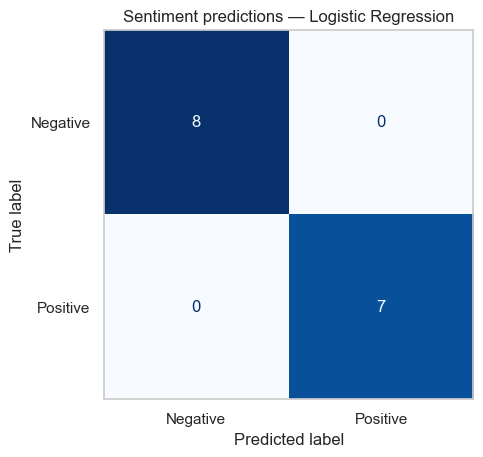

In [8]:
print(classification_report(y_test, best_result["predictions"]))

fig, ax = plt.subplots(figsize=(5.8, 4.8))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_result["predictions"], labels=["negative", "positive"],
    display_labels=["Negative", "Positive"], cmap="Blues", colorbar=False, ax=ax
)
ax.set_title(f"Sentiment predictions — {best_name}")
plt.grid(False)
plt.show()

## 7. Viewing predictive words

Logistic-regression coefficients show which words push a prediction toward positive or negative.


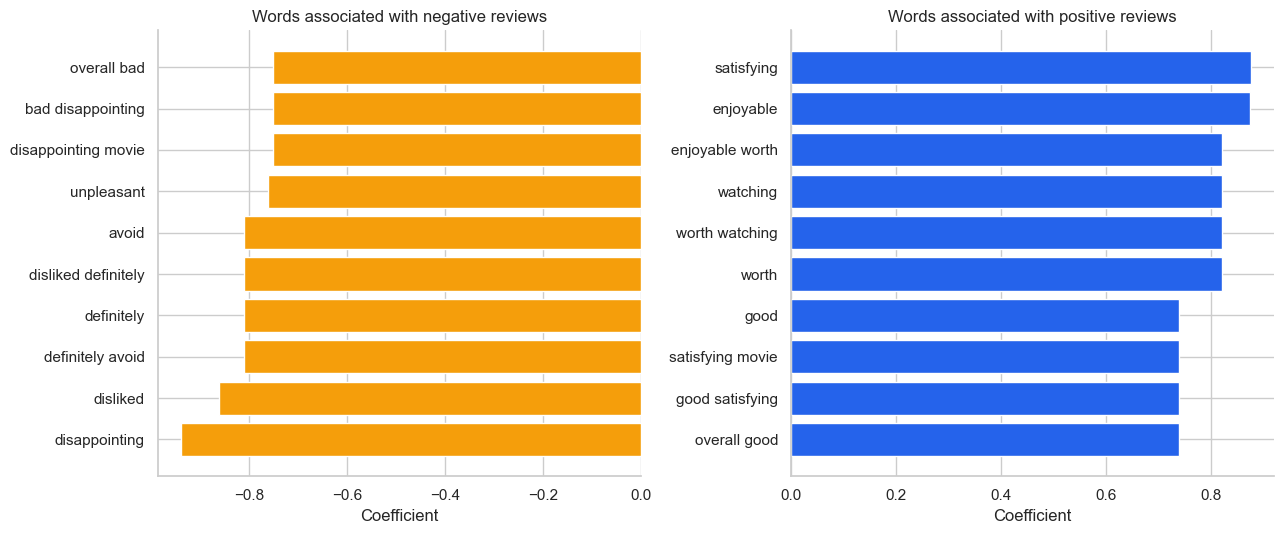

In [9]:
logistic_pipeline = results["Logistic Regression"]["pipeline"]
feature_names = np.array(logistic_pipeline.named_steps["tfidf"].get_feature_names_out())
coefficients = logistic_pipeline.named_steps["classifier"].coef_[0]
top_n = 10
positive_idx = np.argsort(coefficients)[-top_n:]
negative_idx = np.argsort(coefficients)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].barh(feature_names[negative_idx], coefficients[negative_idx], color="#F59E0B")
axes[0].set(title="Words associated with negative reviews", xlabel="Coefficient")
axes[1].barh(feature_names[positive_idx], coefficients[positive_idx], color="#2563EB")
axes[1].set(title="Words associated with positive reviews", xlabel="Coefficient")
for ax in axes:
    ax.set_ylabel("")
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 8. predicting new reviews


In [10]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    label = logistic_pipeline.predict([cleaned])[0]
    probability = logistic_pipeline.predict_proba([cleaned]).max()
    return {"review": text, "sentiment": label, "confidence": round(probability, 3)}

new_reviews = [
    "This movie was an absolute masterpiece with excellent performances.",
    "Terrible plot, wooden acting and a complete waste of time.",
    "It had a few good moments but the ending was disappointing.",
]
pd.DataFrame([predict_sentiment(review) for review in new_reviews])

,review,sentiment,confidence
0,This movie was an absolute masterpiece with ex...,positive,0.582
1,"Terrible plot, wooden acting and a complete wa...",negative,0.568
2,It had a few good moments but the ending was d...,negative,0.514


## 9. Saving the complete pipeline

The saved file includes both TF-IDF and logistic regression, so new text can be passed directly to `.predict()`.


In [11]:
sentiment_path = MODEL_DIR / "sentiment_model.joblib"
joblib.dump(logistic_pipeline, sentiment_path)
print("Saved to:", sentiment_path.resolve())

Saved to: D:\development\sdc_traing_2026\day_5\Pracs\models\sentiment_model.joblib


## my lessons learned

- TF-IDF converts text into numeric features without learning from the test set.
- A pipeline keeps preprocessing and prediction together.
- Coefficients help explain which words influence logistic regression.
- The small local dataset is for teaching; a real system needs far more varied reviews.
